
# Predicting H1N1 Flu Vaccine Uptake


## Project Overview

This project aims to predict whether individuals received the H1N1 flu vaccine using data from the National 2009 H1N1 Flu Survey. The dataset includes demographic information, health-related behaviors, and public perceptions about vaccines. The goal is to build a binary classification model that estimates the likelihood of vaccination for each individual. By analyzing patterns in the data, the model will help identify key factors that influence vaccine uptake. This project is important for public health, as understanding vaccination behavior can help improve campaign strategies, increase vaccine coverage, and reduce the spread of infectious diseases.

## Business Understanding

Vaccination plays a major role in preventing infectious diseases, but not everyone chooses to get vaccinated. This can be due to several challenges, such as:

- Vaccine hesitancy
- Limited access to healthcare
- Lack of awareness or misinformation
- Differences in social and economic background

Because of these challenges, public health organizations need better ways to understand and predict vaccination behavior.

#### Problem Statement

The main problem is to identify which individuals are likely or unlikely to receive the H1N1 vaccine. Solving this problem can help improve how vaccination programs are planned and delivered.

#### Type of Problem

This is a supervised classification problem, where the goal is to predict whether an individual will receive the H1N1 vaccine (Yes or No).

#### Stakeholders

The results of this project can benefit:

1. Public health organizations → to design effective vaccination campaigns
2. Government policymakers → to create policies that improve vaccine coverage
3. Healthcare providers and hospitals → to identify and educate patients who may be hesitant

#### Key Questions

This project aims to answer the following questions:

1. What factors influence whether a person gets vaccinated?
2. Can vaccination behavior be predicted using demographic and behavioral data?
3. Which groups are least likely to receive the vaccine?
4. How do perceptions (such as risk and trust) affect vaccination decisions?
5. Which features are the strongest predictors of vaccine uptake?

#### Objectives

The main objective of this project is:
- To build a predictive classification model that estimates the likelihood of an individual receiving the H1N1 vaccine.

##### Specific Objectives
1. To build a supervised classification model that predicts whether an individual is likely to receive the H1N1 vaccine
2. To use demographic, behavioral, and health-related features as predictors
3. To identify the key factors that influence vaccination decisions
4. To evaluate model performance using appropriate metrics such as:
    - Recall (to correctly identify vaccinated individuals)
    - F1-score (to balance precision and recall)

#### Success Criteria
1. The model should achieve high recall for the vaccinated group, ensuring that most vaccinated individuals are correctly identified
2. The model should also maintain a good balance between precision and recall
3. The model should perform better than a simple baseline model



## Data Understanding

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Reading the dataset into a pandas dataframe 
df=pd.read_csv("H1N1_Flu_Vaccines.csv")
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [3]:
# checking the shape of the dataset
df.shape

(26707, 38)

The dataset has 26707 rows and 38 columns.

In [4]:
# checking the infomation of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

The dataset has 26,707 rows and 38 columns, with each row representing a respondent. It includes behavioral, medical, and opinion-related variables about vaccines. Most variables are numerical, with some categorical features. There are missing values in several columns, so data cleaning will be needed before analysis. The target variables are `h1n1_vaccine` and `seasonal_vaccine`.

In [5]:
# Display data types of all columns
df.dtypes

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numerical Columns:
 Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='str')

Categorical Columns:
 Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='str')


The dataset contains a mix of numerical and categorical variables.


In [6]:
# Check missing values
missing_values = df.isnull().sum()

# Display columns with missing values only
missing_values.sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_seasonal            2160
doctor_recc_h1n1                2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_children               249
household_adults                 249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

<Axes: >

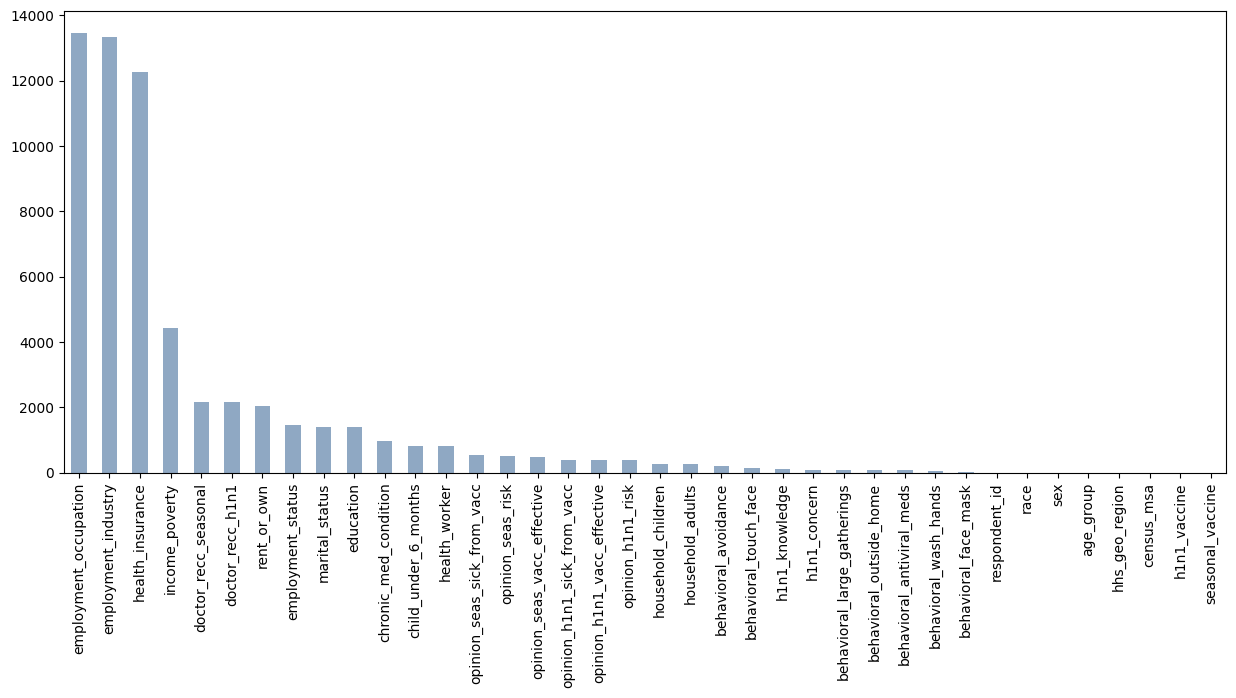

In [7]:
# Frequency of null values in each columns
missing_values.sort_values(ascending=False).plot(kind='bar', figsize=(15,6), color="#8FA8C3")

The dataset contains missing values across several features.

In [8]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

employment_occupation          50.436215
employment_industry            49.912008
health_insurance               45.957989
income_poverty                 16.561201
doctor_recc_seasonal            8.087767
doctor_recc_h1n1                8.087767
rent_or_own                     7.645936
employment_status               5.477965
marital_status                  5.272026
education                       5.268282
chronic_med_condition           3.635751
child_under_6_months            3.070356
health_worker                   3.010447
opinion_seas_sick_from_vacc     2.010709
opinion_seas_risk               1.924589
opinion_seas_vacc_effective     1.729884
opinion_h1n1_sick_from_vacc     1.479013
opinion_h1n1_vacc_effective     1.464036
opinion_h1n1_risk               1.452803
household_children              0.932340
household_adults                0.932340
behavioral_avoidance            0.778822
behavioral_touch_face           0.479275
h1n1_knowledge                  0.434343
h1n1_concern    

In [9]:
# Checkingthe summary statistics of the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.0,13353.000000,7709.791156,0.0,6676.5,13353.0,20029.5,26706.0
h1n1_concern,26615.0,1.618486,0.910311,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.262532,0.618149,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.048844,0.215545,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.725612,0.446214,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.068982,0.253429,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.825614,0.379448,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.358640,0.479610,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,26625.0,0.337315,0.472802,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,26579.0,0.677264,0.467531,0.0,0.0,1.0,1.0,1.0


In [10]:
# Find the duplicated rows
df.duplicated().sum()

np.int64(0)

The dataset hs no duplicated rows.

#### Visualization for EDA

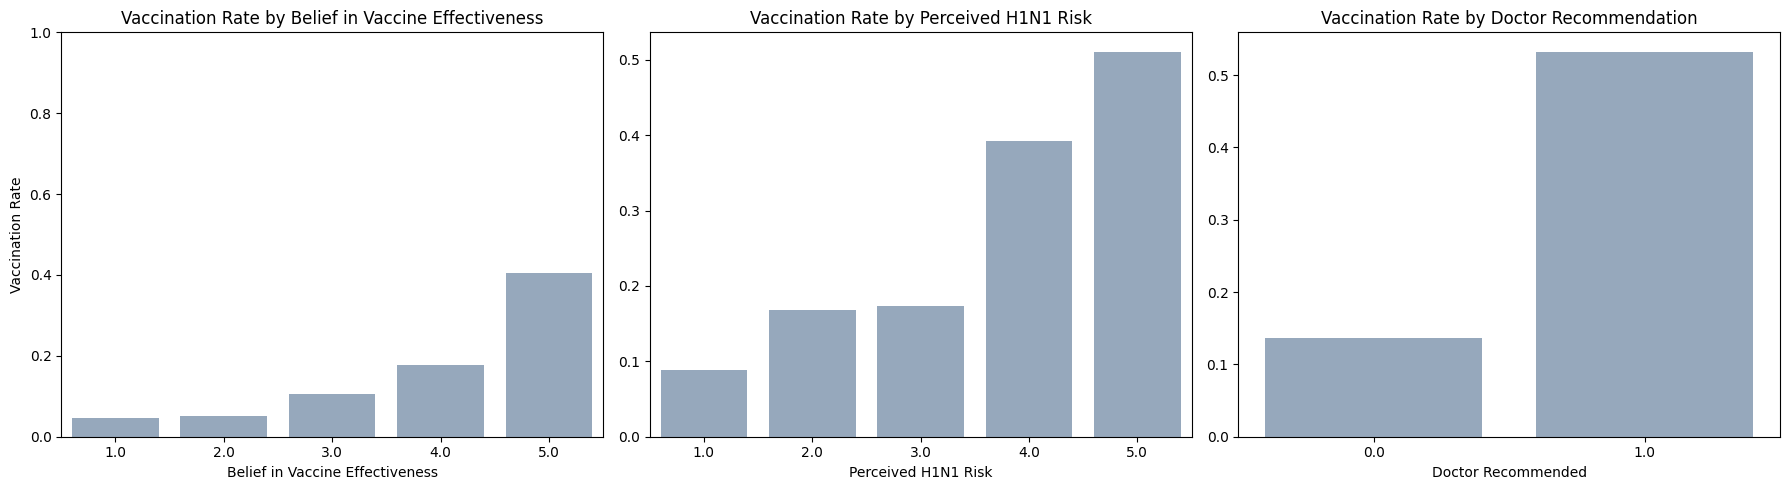

In [11]:
# visualization for EDA
plt.figure(figsize=(18,5))

# 1. Vaccine effectiveness opinion
plt.subplot(1,3,1)
sns.barplot(
    x='opinion_h1n1_vacc_effective',
    y='h1n1_vaccine',
    data=df,
    ci=None,
    color = "#8FA8C3"
)
plt.title("Vaccination Rate by Belief in Vaccine Effectiveness")
plt.xlabel("Belief in Vaccine Effectiveness")
plt.ylabel("Vaccination Rate")
plt.ylim(0,1)

# 2. Perceived risk
plt.subplot(1,3,2)
sns.barplot(
    x='opinion_h1n1_risk',
    y='h1n1_vaccine',
    data=df,
    ci=None,
    color = "#8FA8C3"
)
plt.title("Vaccination Rate by Perceived H1N1 Risk")
plt.xlabel("Perceived H1N1 Risk")
plt.ylabel("")

# 3. Doctor recommendation
plt.subplot(1,3,3)
sns.barplot(
    x='doctor_recc_h1n1',
    y='h1n1_vaccine',
    data=df,
    ci=None,
    color = "#8FA8C3"
)
plt.title("Vaccination Rate by Doctor Recommendation")
plt.xlabel("Doctor Recommended")
plt.ylabel("")

plt.tight_layout()
plt.savefig('images/eda_plot.png')
plt.show()




**Vaccine Effectiveness (opinion_h1n1_vacc_effective):** The chart shows that as the respondent's opinion of the vaccine's effectiveness increases from "Not at all effective" (1) to "Very effective" (5), the vaccination rate also goes up significantly. This indicates that people who trust the vaccine's ability to work are much more likely to actually get vaccinated.

**H1N1 Risk (opinion_h1n1_risk):** The chart shows that for respondents who believe the risk of getting sick without the vaccine is "Very high" (5), the vaccination rate is much higher compared to those who feel the risk is "Very low" (1). This suggests that a person's fear of getting sick is a major factor in their decision to get vaccinated.

**Doctor Recommendations (doctor_recc_h1n1):** The chart shows that for respondents who received a "Yes" (1) recommendation from their doctor, the vaccination rate is much higher than for those who did not receive one (0). 

### Class Distribution

In [12]:
# Check the distribution of the target variable for H1N1 vaccine uptake
print(df["h1n1_vaccine"].value_counts())

# Check the distribution of the target variable for seasonal flu vaccine uptake
print(df["seasonal_vaccine"].value_counts())

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


From the above output, we can see that the h1n1 vaccine target class is imbalanced. The seasonal vaccine class is more balanced. A very small rate of people received both seasonal as well as h1n1 vaccines.

Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.

In [13]:
# Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.
only_h1n1 = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

only_seasonal = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

both = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

neither = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

# print results
print("Only H1N1:", only_h1n1)
print("Only Seasonal:", only_seasonal)
print("Both Vaccines:", both)
print("Neither:", neither)

Only H1N1: 0.03658216946867862
Only Seasonal: 0.2897367731306399
Both Vaccines: 0.17587149436477328
Neither: 0.4978095630359082


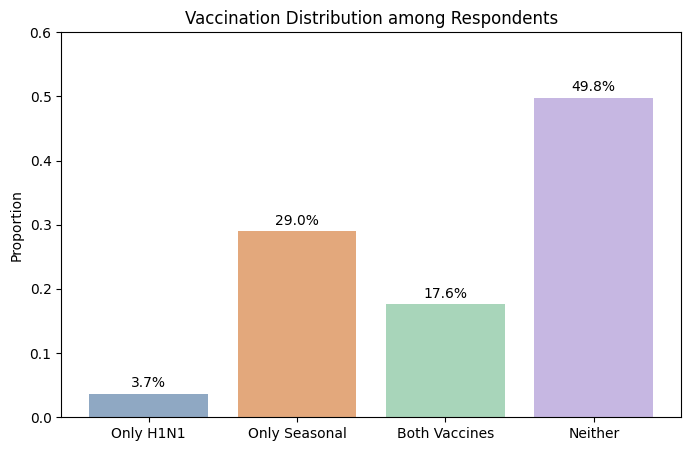

In [14]:
# categories and their proportions
categories = ["Only H1N1", "Only Seasonal", "Both Vaccines", "Neither"]
proportions = [0.0366, 0.2897, 0.1759, 0.4978]

# create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(categories, proportions, color = ["#8FA8C3", "#E3A87C", "#A8D5BA", "#C6B7E2"])
plt.title("Vaccination Distribution among Respondents")
plt.ylabel("Proportion")
plt.ylim(0, 0.6)

# add percentage labels on top of bars
for bar, prop in zip(bars, proportions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{prop*100:.1f}%", ha='center', fontsize=10)

plt.show()



From the above vaccination distribution analysis, about 3.7% of respondents took only the H1N1 vaccine, 29.0% took only the seasonal vaccine, 17.6% took both, and 49.8% took neither, showing that almost half did not receive any vaccine.

## 3. Data preparation

For this project, I chose to focus on H1N1 vaccination as the target variable.

The goal is to predict whether an individual received the H1N1 vaccine based on their background, opinions, and health-related behaviors. This decision was made because H1N1 represents a specific pandemic scenario, making it more relevant for understanding vaccination behavior during public health emergencies.

##### Dropping Columns with Many Missing Values

In this step, columns with a high number of missing values are removed to improve data quality. The `respondent_id` column is also dropped since it only serves as an identifier and does not contribute to the analysis. Additionally, the `doctor_recc_seasonal` column is removed because the `seasonal_vaccine` variable is not being used as the target in this model.

In [15]:
# drop the columns with many missing values 
df.drop(["employment_occupation", "employment_industry", "health_insurance", "respondent_id", "doctor_recc_seasonal"], axis=1, inplace=True)

##### Splitting Features and Target Variables

In this step, we separate the dataset into input features (`X`) and target variables (`y`).

In [16]:
x=df.drop(["h1n1_vaccine", "seasonal_vaccine"], axis=1)
y=df["h1n1_vaccine"]

For this project, 
the target variable is h1n1_vaccine, which indicates whether an individual received the H1N1 vaccine:
1 → Vaccinated
0 → Not vaccinated
The predictor variables include all other features in the dataset, which are used to predict the target outcome.

##### Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate the model's performance.

In [17]:
# splitting the dataset into training and testing
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((21365, 31), (5342, 31), (21365,), (5342,))

Data preparation for the x_train

In [18]:
x_train.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,White,Female,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,White,Male,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,White,Male,NaN,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Other or Multiple,Female,NaN,Not Married,Own,Employed,bhuqouqj,Non-MSA,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,1.0


In [19]:
# checking for missing values in the x_train dataset
print(x_train.isna().sum().sort_values(ascending=False))


income_poverty                 3514
doctor_recc_h1n1               1736
rent_or_own                    1628
employment_status              1162
education                      1125
marital_status                 1120
chronic_med_condition           771
child_under_6_months            655
health_worker                   643
opinion_seas_sick_from_vacc     431
opinion_seas_risk               410
opinion_seas_vacc_effective     371
opinion_h1n1_sick_from_vacc     321
opinion_h1n1_vacc_effective     318
opinion_h1n1_risk               311
household_adults                202
household_children              202
behavioral_avoidance            163
behavioral_touch_face           102
h1n1_knowledge                   91
h1n1_concern                     73
behavioral_large_gatherings      72
behavioral_antiviral_meds        59
behavioral_outside_home          59
behavioral_wash_hands            36
behavioral_face_mask             14
age_group                         0
sex                         

In [20]:
# checking for missing values in the x_test dataset
print(x_test.isna().sum().sort_values(ascending=False))

income_poverty                 909
doctor_recc_h1n1               424
rent_or_own                    414
employment_status              301
marital_status                 288
education                      282
chronic_med_condition          200
child_under_6_months           165
health_worker                  161
opinion_seas_sick_from_vacc    106
opinion_seas_risk              104
opinion_seas_vacc_effective     91
opinion_h1n1_risk               77
opinion_h1n1_sick_from_vacc     74
opinion_h1n1_vacc_effective     73
household_adults                47
household_children              47
behavioral_avoidance            45
behavioral_touch_face           26
h1n1_knowledge                  25
behavioral_outside_home         23
h1n1_concern                    19
behavioral_large_gatherings     15
behavioral_antiviral_meds       12
behavioral_wash_hands            6
behavioral_face_mask             5
age_group                        0
sex                              0
race                

#### Handling missing values for the x_train and the x_test

Ordinal numerical columns

In [21]:
# handling missing values for the numerical columns
x_train.select_dtypes("float64").isna().sum()


h1n1_concern                     73
h1n1_knowledge                   91
behavioral_antiviral_meds        59
behavioral_avoidance            163
behavioral_face_mask             14
behavioral_wash_hands            36
behavioral_large_gatherings      72
behavioral_outside_home          59
behavioral_touch_face           102
doctor_recc_h1n1               1736
chronic_med_condition           771
child_under_6_months            655
health_worker                   643
opinion_h1n1_vacc_effective     318
opinion_h1n1_risk               311
opinion_h1n1_sick_from_vacc     321
opinion_seas_vacc_effective     371
opinion_seas_risk               410
opinion_seas_sick_from_vacc     431
household_adults                202
household_children              202
dtype: int64

In [22]:
x_test.select_dtypes("float64").isna().sum()

h1n1_concern                    19
h1n1_knowledge                  25
behavioral_antiviral_meds       12
behavioral_avoidance            45
behavioral_face_mask             5
behavioral_wash_hands            6
behavioral_large_gatherings     15
behavioral_outside_home         23
behavioral_touch_face           26
doctor_recc_h1n1               424
chronic_med_condition          200
child_under_6_months           165
health_worker                  161
opinion_h1n1_vacc_effective     73
opinion_h1n1_risk               77
opinion_h1n1_sick_from_vacc     74
opinion_seas_vacc_effective     91
opinion_seas_risk              104
opinion_seas_sick_from_vacc    106
household_adults                47
household_children              47
dtype: int64


All the ordinal numerical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column. This method is appropriate because ordinal features represent ordered categories, and using the mode helps preserve the most common and meaningful responses without changing the data.

In [23]:
# selecting the columns with float data types
x_train_float=x_train.select_dtypes('float64')
x_test_float=x_test.select_dtypes("float64")


# initializing the simple imputer class and using the mode strategy to fill the missing values
imputer=SimpleImputer(strategy="most_frequent")
imputer.fit(x_train_float)
x_train_filled_float=pd.DataFrame(imputer.transform(x_train_float), index=x_train_float.index, 
                          columns=x_train_float.columns)
x_test_filled_float=pd.DataFrame(imputer.transform(x_test_float), index=x_test_float.index, 
                          columns=x_test_float.columns)
x_train_float= x_train_filled_float
x_test_float= x_test_filled_float

In [24]:
x_train_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

In [25]:
x_test_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

#### Handling missing values for the categorical columns


Some categorical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column.



In [26]:
x_train_cat= x_train.select_dtypes("object")
x_train_cat.isna().sum()

age_group               0
education            1125
race                    0
sex                     0
income_poverty       3514
marital_status       1120
rent_or_own          1628
employment_status    1162
hhs_geo_region          0
census_msa              0
dtype: int64

In [27]:
x_test_cat=x_test.select_dtypes("object")
x_test_cat.isna().sum()

age_group              0
education            282
race                   0
sex                    0
income_poverty       909
marital_status       288
rent_or_own          414
employment_status    301
hhs_geo_region         0
census_msa             0
dtype: int64

In [28]:
# selecting the x_train columns with string data types
x_train_cat= x_train.select_dtypes("object")
x_test_cat=x_test.select_dtypes("object")

# creating a variable called cat_cols that has the columns with the missing values
cat_cols=["education","income_poverty", "marital_status","rent_or_own","employment_status"]

# filling the missing values with the mode strategy using the simpleimputer method
imputer=SimpleImputer(strategy="most_frequent")
imputer.fit(x_train_cat[cat_cols])
x_train_cat_filled=pd.DataFrame(imputer.transform(x_train_cat[cat_cols]), index=x_train_cat[cat_cols].index, 
                        columns=x_train_cat[cat_cols].columns)

x_test_cat_filled=pd.DataFrame(imputer.transform(x_test_cat[cat_cols]), index=x_test_cat[cat_cols].index, 
                        columns=x_test_cat[cat_cols].columns)

x_train_cat_filled= x_train_cat_filled
x_test_cat_filled= x_test_cat_filled


In [29]:
x_train_cat_filled.isna().sum()

education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [30]:
x_test_cat_filled.isna().sum()

education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [31]:
# Concatinating the filled columns to form one x_train dataframe 
x_train_full=pd.concat([x_train_float, x_train_cat_filled, 
                       x_train_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,Below Poverty,Married,Rent,Unemployed,45 - 54 Years,White,Female,"MSA, Not Principle City",lzgpxyit
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"> $75,000",Not Married,Own,Employed,45 - 54 Years,White,Male,"MSA, Not Principle City",lzgpxyit
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Not Principle City",qufhixun
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Employed,45 - 54 Years,Other or Multiple,Female,Non-MSA,bhuqouqj
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,65+ Years,Black,Female,"MSA, Principle City",mlyzmhmf


In [32]:
# Concatinating the filled columnst to form one x_train dataframe 
x_test_full=pd.concat([x_test_float, x_test_cat_filled, 
                       x_test_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [33]:
x_test_full["rent_or_own"].isna().sum()

np.int64(0)

### Mapping the Categorical columns

Mapping the train columns

In [34]:
x_train_full["education"].unique()

<StringArray>
['Some College', 'College Graduate', '12 Years', '< 12 Years']
Length: 4, dtype: str

In [35]:
# Replace specific education levels with broader categories
# "< 12 Years" is recoded as "Primary School"
# "12 Years" is recoded as "Secondary School"
x_train_full["education"]=x_train_full["education"].replace({"12 Years": "Secondary School", 
                                                             "< 12 Years":"Primary School"})

# Display the unique values in the education column to verify the changes
x_train_full["education"].unique()

<StringArray>
['Some College', 'College Graduate', 'Secondary School', 'Primary School']
Length: 4, dtype: str

The `education` column was simplified by grouping similar levels. "< 12 Years" was recoded as "Primary School" and "12 Years" as "Secondary School". 

In [36]:
x_train_full["income_poverty"].unique()

<StringArray>
['Below Poverty', '> $75,000', '<= $75,000, Above Poverty']
Length: 3, dtype: str

In [37]:
# Recode income levels into simpler categories for easier analysis
# "> $75,000" → "High_income"
# "<= $75,000, Above Poverty" → "Average Income"
# "Below Poverty" → "Low Income"
x_train_full["income_poverty"]=x_train_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_train_full["income_poverty"].unique()

<StringArray>
['Low Income', 'High_income', 'Average Income']
Length: 3, dtype: str

The `income_poverty` column was recoded into simpler and more meaningful categories. Higher income levels were grouped as "High_income", middle income as "Average Income", and lower income as "Low Income". 

Mapping the test data

In [38]:
x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', '12 Years', '< 12 Years']
Length: 4, dtype: str

In [39]:
x_test_full["education"]=x_test_full["education"].replace({"12 Years": "Secondary School", "< 12 Years":"Primary School"})

x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', 'Secondary School', 'Primary School']
Length: 4, dtype: str

In [40]:
x_test_full["income_poverty"].unique()

<StringArray>
['<= $75,000, Above Poverty', '> $75,000', 'Below Poverty']
Length: 3, dtype: str

In [41]:
x_test_full["income_poverty"]=x_test_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_test_full["income_poverty"].unique()

<StringArray>
['Average Income', 'High_income', 'Low Income']
Length: 3, dtype: str

In [42]:
x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,High_income,Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,High_income,Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [43]:
x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,Low Income,Married,Rent,Unemployed,45 - 54 Years,White,Female,"MSA, Not Principle City",lzgpxyit
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,High_income,Not Married,Own,Employed,45 - 54 Years,White,Male,"MSA, Not Principle City",lzgpxyit
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Not Principle City",qufhixun
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,Average Income,Not Married,Own,Employed,45 - 54 Years,Other or Multiple,Female,Non-MSA,bhuqouqj
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,Average Income,Not Married,Own,Not in Labor Force,65+ Years,Black,Female,"MSA, Principle City",mlyzmhmf


#### Creating a new feature (the preventive_behavior score)

In [44]:
# Create a new feature called "preventive_behavior" by combining key protective actions
x_train_full["preventive_behavior"] = (
    x_train_full["behavioral_antiviral_meds"] +
    x_train_full["behavioral_avoidance"] +
    x_train_full["behavioral_face_mask"] +
    x_train_full["behavioral_wash_hands"]
)

# Apply the same feature creation to the test dataset 
x_test_full["preventive_behavior"] = (
    x_test_full["behavioral_antiviral_meds"] +
    x_test_full["behavioral_avoidance"] +
    x_test_full["behavioral_face_mask"] +
    x_test_full["behavioral_wash_hands"]
)

A new feature called `preventive_behavior` was created by adding together different protective actions like using antiviral medication, avoiding contact, wearing masks, and washing hands. This helps to summarize a person's overall preventive behavior in one value.

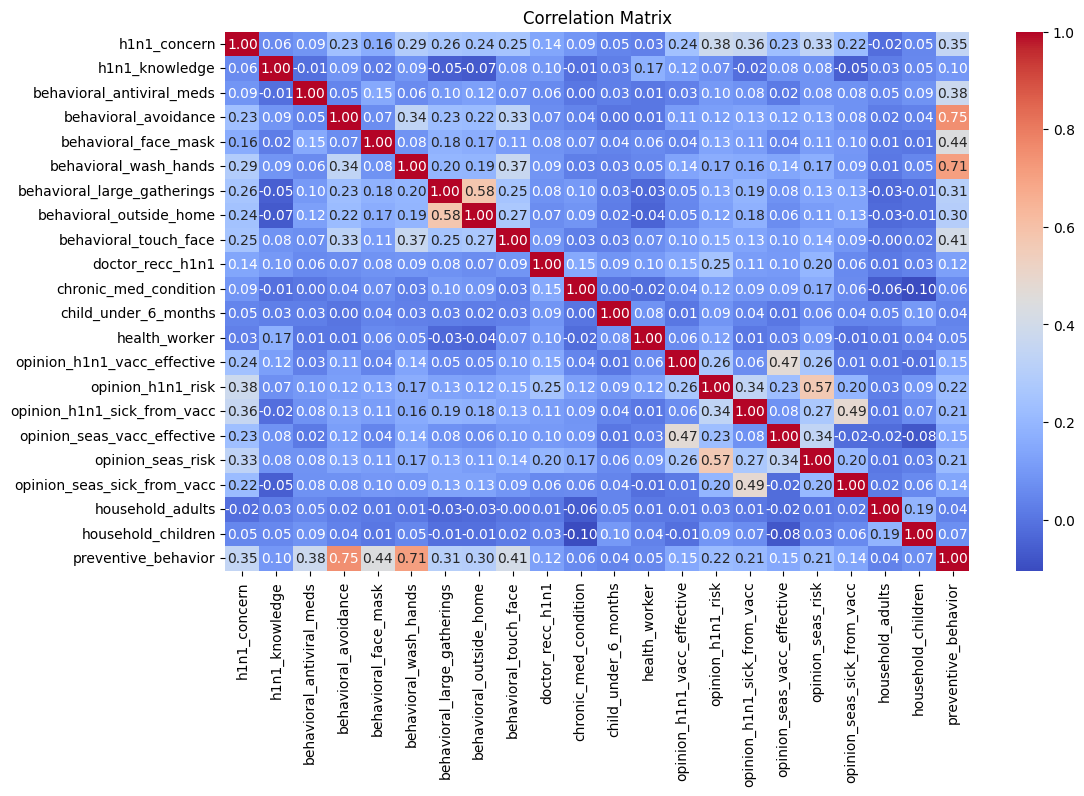

In [45]:
# Creating a correlation matrix 
# Keep only numeric columns
numeric_cols = x_train_full.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

A correlation analysis showed that these new features were highly correlated with their original components. To reduce redundancy and multicollinearity, the original columns contributing to these sums need to be dropped.

In [46]:
cols_to_drop = [
    "behavioral_antiviral_meds", 
    "behavioral_avoidance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
]

x_train_full = x_train_full.drop(columns=cols_to_drop)
x_test_full = x_test_full.drop(columns=cols_to_drop)

### OneHotEncoding the Categorical columns



In [47]:
print(x_train.select_dtypes("object").columns)
print(x_test.select_dtypes("object").columns)

Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')
Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')


In [48]:
# Initializing the onehotencoder class
ohe=OneHotEncoder(sparse_output=False, drop="first")

# creating a variable called ohe_columns that contain the columns to be encoded
ohe_cols=['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa']
ohe.fit(x_train_full[ohe_cols])
x_train_ohe=pd.DataFrame(ohe.transform(x_train_full[ohe_cols]), index=x_train_full[ohe_cols].index,
                         columns=ohe.get_feature_names_out())

x_test_ohe=pd.DataFrame(ohe.transform(x_test_full[ohe_cols]), index=x_test_full[ohe_cols].index,
                         columns=ohe.get_feature_names_out())

x_train_ohe.head()

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_Primary School,education_Secondary School,education_Some College,race_Hispanic,race_Other or Multiple,race_White,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5393,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3429,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8731,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [49]:
x_test_ohe.head()

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_Primary School,education_Secondary School,education_Some College,race_Hispanic,race_Other or Multiple,race_White,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
15772,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [50]:
x_train_full=x_train_full.drop(ohe_cols, axis=1)
x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior
24706,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,4.0,2.0,4.0,4.0,2.0,1.0,0.0,2.0
5393,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,5.0,4.0,4.0,5.0,4.0,4.0,0.0,0.0,4.0
20898,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,1.0,4.0,2.0,2.0,0.0,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,5.0,5.0,2.0,5.0,1.0,1.0,1.0


In [51]:
x_test_full=x_test_full.drop(ohe_cols, axis=1)
x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior
15772,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,2.0,1.0,1.0,0.0,3.0
9407,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,2.0,1.0,1.0,1.0,3.0
16515,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,4.0,1.0,0.0,1.0,2.0
23353,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,2.0,4.0,2.0,1.0,1.0,2.0,2.0
10008,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,2.0,2.0,4.0,1.0,2.0,1.0,0.0,2.0


In [52]:
X_train_full=pd.concat([x_train_full, x_train_ohe], axis=1)
X_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8731,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [53]:
X_test_full=pd.concat([x_test_full, x_test_ohe], axis=1)
X_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
15772,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Scaling the data using the Standard Scaler

In [54]:
# Specifying the columns to be scaled
cols_to_scale = [
    'h1n1_knowledge',
    'opinion_h1n1_vacc_effective',
    'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective',
    'opinion_seas_risk',
    'opinion_seas_sick_from_vacc',
    'household_adults',
    'household_children',
    "h1n1_concern",
    "opinion_h1n1_risk"
]

X_train_scaled = X_train_full.copy()
X_test_scaled = X_test_full.copy()

# Instanciating the standardscaler class
sc = StandardScaler()

X_train_scaled[cols_to_scale] = sc.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = sc.transform(X_test_scaled[cols_to_scale])

#### Handling class imbalance for the target variable Using SMOTE Method

In [55]:
# Display the count of each class in the target variable y_train
print(y_train.value_counts())

# Display the proportion of each class in y_train to understand class balance
print(y_train.value_counts(normalize=True))

h1n1_vaccine
0    16821
1     4544
Name: count, dtype: int64
h1n1_vaccine
0    0.787316
1    0.212684
Name: proportion, dtype: float64


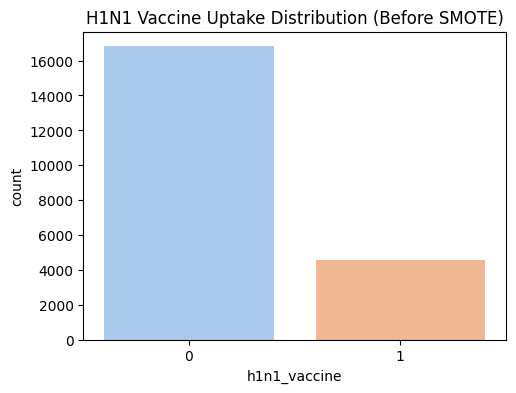

In [56]:
# Plot the distribution of the target variable y_train

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.countplot(x=y_train, palette='pastel')
plt.title("H1N1 Vaccine Uptake Distribution (Before SMOTE)")
plt.show()

The target variable (`h1n1_vaccine`) shows a clear class imbalance. The majority class (0 – individuals who did not receive the vaccine) has 14,714 observations, while the minority class (1 – individuals who received the vaccine) has only 3,980 observations.

This imbalance indicates that the dataset is skewed toward the non-vaccinated group. As a result, machine learning models trained on this data may become biased toward predicting the majority class, potentially reducing the model’s ability to correctly identify vaccinated individuals. 

In [57]:
# Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the target classes
# This generates synthetic samples for the minority class to reduce class imbalance
smote = SMOTE(random_state=42)
X_train_full_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check the new class distribution after applying SMOTE
pd.Series(y_train_smote).value_counts()

h1n1_vaccine
0    16821
1    16821
Name: count, dtype: int64

In [58]:
X_train_full.shape, X_test_full.shape, y_train.shape, y_test.shape

((21365, 46), (5342, 46), (21365,), (5342,))

## Model creation

### Creating a model with imbalanced dataset(baseline model)


In [59]:
# Initialize Logistic Regression model
model = LogisticRegression(solver="liblinear")

# Train the model on the full training dataset
model.fit(X_train_full, y_train)

scores = model.decision_function(X_test_scaled)

# Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for ROC curve
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test, scores)

# Calculate AUC (Area Under the Curve) to evaluate model performance
auc = roc_auc_score(y_test, scores)
print(auc)

# Generate predicted class labels for the test set
y_pred = model.predict(X_test_scaled)

# Print confusion matrix to evaluate classification performance
print(confusion_matrix(y_test, y_pred))

# Print detailed classification report (precision, recall, F1-score)
print(classification_report(y_test, y_pred))

0.8211775878442547
[[4212    0]
 [1130    0]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      4212
           1       0.00      0.00      0.00      1130

    accuracy                           0.79      5342
   macro avg       0.39      0.50      0.44      5342
weighted avg       0.62      0.79      0.70      5342



The baseline Logistic Regression model may achieve high accuracy due to class imbalance, but it often performs poorly in identifying the minority class.
It predicted only the majority class (no vaccine), resulting in zero recall for the minority class (vaccine). This occurred due to class imbalance, where approximately 79% of observations belong to class 0 and only 21% to class 1. Although the model achieved a relatively high ROC-AUC score, it failed to correctly classify individuals who received the H1N1 vaccine, demonstrating that accuracy and AUC alone can be misleading in imbalanced datasets. Therefore, metrics such as recall and F1-score are more important for evaluating model performance in this problem.

To address this issue, SMOTE resampling technique was used to balance the dataset, enabling the model to better learn patterns associated with the minority class and improve its predictive performance.

### Creating a model with balanced dataset 

#### Model Evaluation Function

This cell defines a reusable function `evaluate_model` that trains a given model and evaluates its performance on test data. It computes prediction scores, generates the ROC curve and AUC score, and prints the confusion matrix along with a classification report. 

In [60]:
# Set plotting style for consistency and better visualization
plt.style.use('ggplot')

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Get prediction scores:
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve values (FPR, TPR) and thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    
    # Calculate AUC score to evaluate model performance
    auc = roc_auc_score(y_test, y_scores)
    
    # Generate predicted class labels
    y_pred = model.predict(X_test)
    
    # Print model evaluation results
    print(f"\n===== {model_name} =====")
    print(f"AUC Score: {auc:.3f}")
    
    # Display confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Display classification metrics: precision, recall, F1-score
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return fpr, tpr, auc

### Top Predictors of Vaccine Uptake

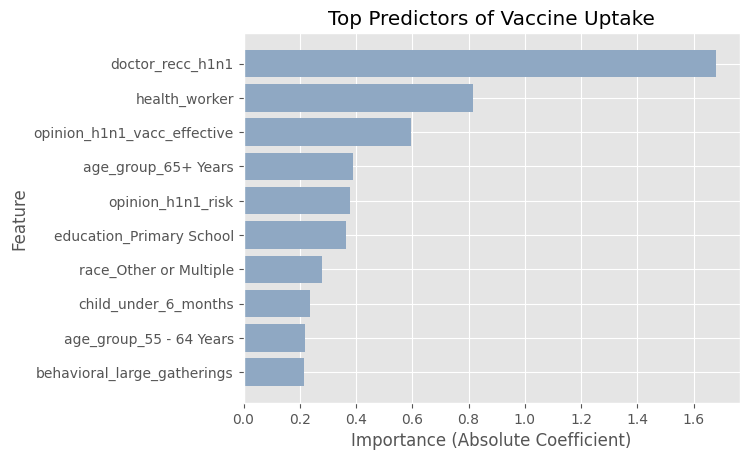

In [61]:
# Create a DataFrame to store feature names and their corresponding coefficients
coefficients = pd.DataFrame({
    'Feature': X_train_full.columns,          # Names of all input features
    'Coefficient': model.coef_[0]             # Coefficients from the trained logistic regression model
})

# Create a new column with absolute values of coefficients
# This helps us measure the strength of each feature regardless of direction (+/-)
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

# Sort features by importance (highest to lowest)
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Select the top 10 most important features
top_features = coefficients.head(10)

# Create a horizontal bar plot
plt.figure()
plt.barh(top_features['Feature'], top_features['Abs_Coefficient'], color="#8FA8C3")
plt.xlabel('Importance (Absolute Coefficient)')
plt.ylabel('Feature')
plt.title('Top Predictors of Vaccine Uptake')

# Invert y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

plt.savefig('images/feature_importance.png')
# Display the plot
plt.show()


This chart shows the most important factors influencing H1N1 vaccine uptake based on model coefficients. Doctor recommendation is the strongest predictor, meaning people are much more likely to get vaccinated if advised by a doctor.

Other key factors include being a health worker, believing the vaccine is effective, older age, and perceived risk of H1N1. While factors like education, having a young child, and social behavior also matter, their impact is smaller.

#### Logistic Regression with SMOTE

In [62]:
# Initialize the Logistic Regression model
smote_model = LogisticRegression(solver="liblinear")

# Evaluate the model using a custom evaluation function
fpr_log, tpr_log, auc_log = evaluate_model(
    smote_model,              # Model to train
    X_train_full_smote,       # Training features after SMOTE (balanced dataset)
    y_train_smote,            # Training labels after SMOTE
    X_test_scaled,            # Scaled test features
    y_test,                   # True test labels
    model_name="Logistic Regression (SMOTE)"  
)



===== Logistic Regression (SMOTE) =====
AUC Score: 0.821
Confusion Matrix:
[[3373  839]
 [ 342  788]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.70      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



#### ROC Curve Visualization for the Logistic Regression model


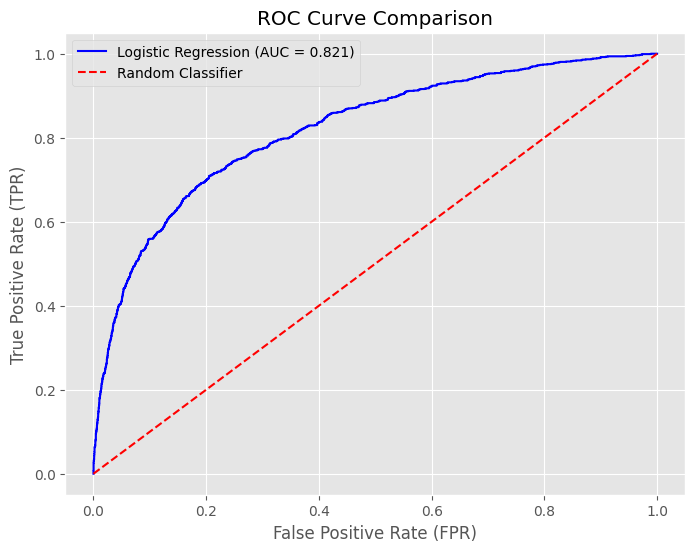

In [63]:
# Plot the ROC curve for the Logistic Regression model

plt.figure(figsize=(8,6))

# Plot the ROC curve for Logistic Regression
plt.plot(fpr_log, tpr_log, color="blue", label=f"Logistic Regression (AUC = {auc_log:.3f})")

# Add a random baseline (diagonal line) for comparison
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#### Logistic Regression (SMOTE) Results

The Logistic Regression model trained on SMOTE-balanced data achieved an AUC score of **0.821**, indicating good overall classification performance. The model demonstrates a strong ability to identify the positive class (class 1), with a recall of **0.70**, meaning it successfully captures most of the actual positive cases.

However, this comes at the cost of lower precision (**0.48**), indicating a higher number of false positives. The overall accuracy of the model is **78%**, with a weighted F1-score of **0.79**, showing a reasonable balance between precision and recall. This performance suggests that applying SMOTE improved the model’s sensitivity to the minority class, making it more effective for problems where detecting positive cases is important.

#### Decision Tree Model

In [64]:
# Initialize the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Evaluate the model using the custom evaluation function
fpr_tree, tpr_tree, auc_tree = evaluate_model(
    decision_tree_model,      # Model to train
    X_train_full_smote,       # Training features after SMOTE (balanced dataset)
    y_train_smote,            # Training labels after SMOTE
    X_test_scaled,            # Scaled test features
    y_test,                   # True test labels
    model_name="Decision Tree"
)


===== Decision Tree =====
AUC Score: 0.649
Confusion Matrix:
[[3524  688]
 [ 608  522]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4212
           1       0.43      0.46      0.45      1130

    accuracy                           0.76      5342
   macro avg       0.64      0.65      0.65      5342
weighted avg       0.76      0.76      0.76      5342



#### ROC Curve Visualization for Decision Tree model


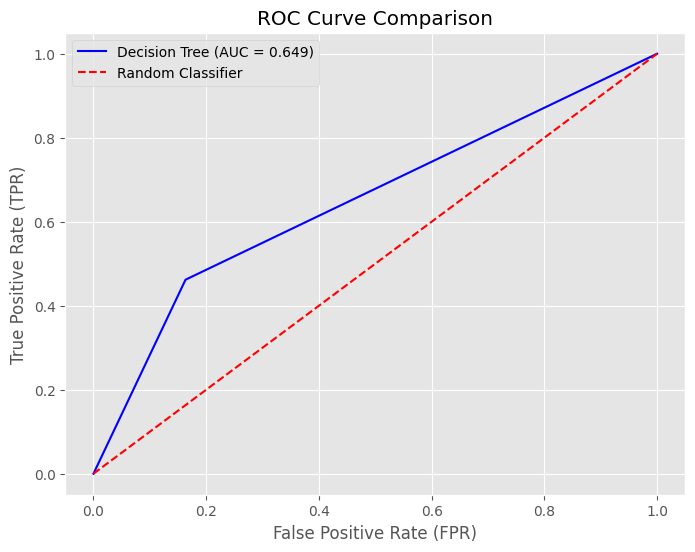

In [65]:
plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, color="blue", label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

**Decision Tree Results**

The Decision Tree model trained on SMOTE-balanced data achieved an **AUC score of 0.649**, indicating moderate ability to distinguish between classes. The model shows strong performance for the majority class (class 0), with precision and recall around **0.85** and **0.84**, respectively.  

However, the minority class (class 1) is less well predicted, with precision **0.43** and recall **0.46**, leading to a lower F1-score of **0.45**. Overall accuracy is **76%**, with a weighted F1-score of **0.76**.  These results suggest that while the Decision Tree captures the majority class well, it struggles to correctly identify positive cases, making it less effective than Logistic Regression for imbalanced data, even after SMOTE.

### ROC Curve Comparison (ROC curves for both Logistic Regression and Decision Tree models)


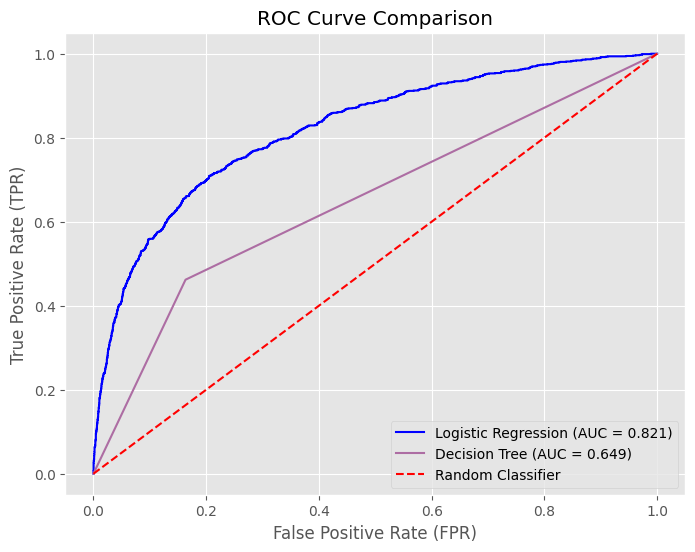

In [66]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, color= "blue",label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree,color= "#AD6DA3", label=f"Decision Tree (AUC = {auc_tree:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve compares the performance of the Logistic Regression and Decision Tree models on the test set. 

- **Logistic Regression** (red curve) achieves an **AUC of 0.821**, indicating strong ability to distinguish between the positive and negative classes.  
- **Decision Tree** (blue curve) has a lower **AUC of 0.649**, showing moderate performance and less effectiveness at identifying the positive class.  
- The **dashed red line** represents a random classifier (AUC = 0.5) for reference.  

From the plot, it is clear that Logistic Regression outperforms the Decision Tree in classifying both majority and minority classes, making it the better model for this imbalanced dataset.

### Hyperparameter Tuning (Logistic Regression)

In [67]:
# Define the hyperparameter grid for Logistic Regression
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Set up GridSearchCV to find the best combination of hyperparameters
grid_logreg = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear'), 
    param_grid=logreg_params,
    scoring='roc_auc',
    cv=5,                                            #5-fold cross-validation
    n_jobs=-1
)

# Fit the grid search on the SMOTE-balanced training data
grid_logreg.fit(X_train_full_smote, y_train_smote)

# Print the best hyperparameters and corresponding cross-validated AUC score
print("Best Logistic Regression Params:", grid_logreg.best_params_)
print("Best CV AUC Score:", grid_logreg.best_score_)

# Extract the best Logistic Regression model found by GridSearchCV
tuned_logreg = grid_logreg.best_estimator_

# Evaluate the tuned model on training (SMOTE) and test (scaled) datasets
fpr_log_tuned, tpr_log_tuned, auc_log_tuned = evaluate_model(
    tuned_logreg,
    X_train_full_smote,
    y_train_smote,
    X_test_scaled,
    y_test,
    model_name="Tuned Logistic Regression (SMOTE)"
)

Best Logistic Regression Params: {'C': 1, 'penalty': 'l1'}
Best CV AUC Score: 0.845336438769921

===== Tuned Logistic Regression (SMOTE) =====
AUC Score: 0.821
Confusion Matrix:
[[3375  837]
 [ 343  787]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.70      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



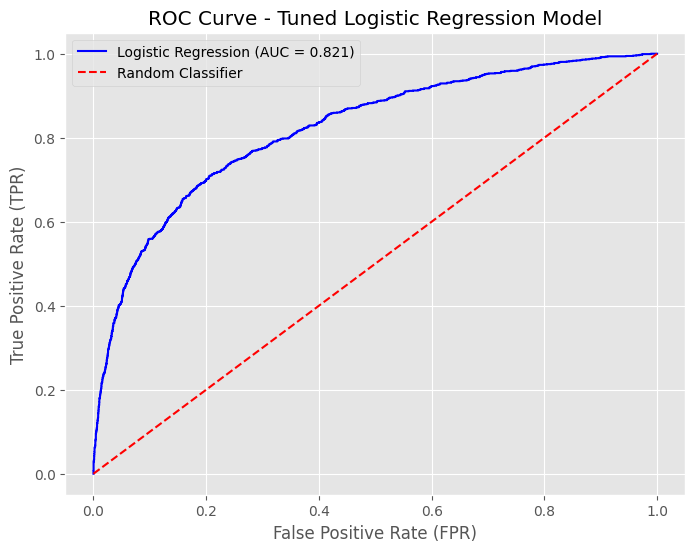

In [68]:
# Plot the ROC curve for the tuned Logistic Regression model

plt.figure(figsize=(8,6))

# ROC curve for the tuned Logistic Regression
plt.plot(fpr_log_tuned, tpr_log_tuned, color='blue', label=f"Logistic Regression (AUC = {auc_log:.3f})")

# Random baseline for comparison
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Tuned Logistic Regression Model")
plt.legend()
plt.show()

The logistic regression model was tuned using GridSearchCV on the SMOTE-balanced training set.  
**Best parameters:** `C = 1`, `penalty = l1` | **Best CV AUC:** 0.845  

On the test set, the model achieved an **AUC of 0.821** and **accuracy of 78%**.  
Class 1 (minority) shows improved recall (0.70) due to SMOTE, while class 0 maintains high precision (0.91). Overall, the tuning and balancing improved the model’s ability to detect the minority class.

### Hyperparameter Tuning (Decision Tree)

In [69]:
# Hyperparameter grid
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

# Fit on SMOTE training data
grid_dt.fit(X_train_full_smote, y_train_smote)

# Best parameters
print("Best Decision Tree Params:", grid_dt.best_params_)
print("Best CV AUC Score:", grid_dt.best_score_)

# Evaluate the tuned model on training (SMOTE) and test (scaled) datasets
fpr_tree_tuned, tpr_tree_tuned, auc_tree_tuned = evaluate_model(
    grid_dt.best_estimator_,
    X_train_full_smote,
    y_train_smote,
    X_test_scaled,
    y_test,
    model_name="Tuned Decision Tree"
)

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV AUC Score: 0.9151368603850522

===== Tuned Decision Tree =====
AUC Score: 0.804
Confusion Matrix:
[[3756  456]
 [ 496  634]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      4212
           1       0.58      0.56      0.57      1130

    accuracy                           0.82      5342
   macro avg       0.73      0.73      0.73      5342
weighted avg       0.82      0.82      0.82      5342



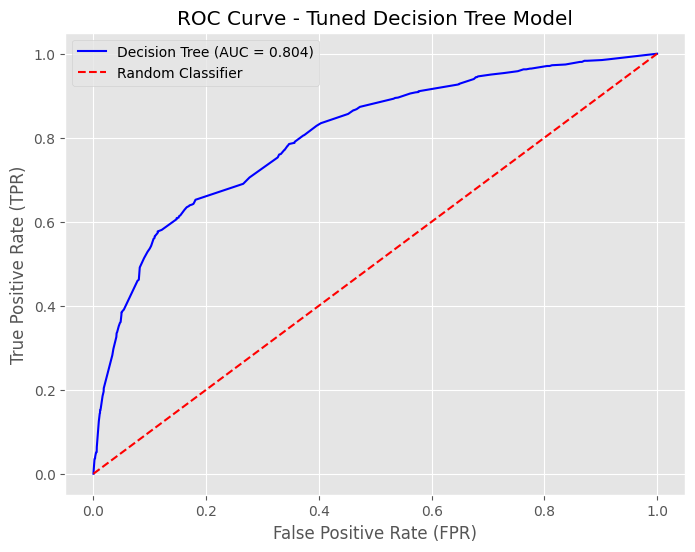

In [70]:
# Plot the ROC curve for the tuned Decision Tree model

plt.figure(figsize=(8,6))

# ROC curve for the tuned Decision Tree
plt.plot(fpr_tree_tuned, tpr_tree_tuned, color='blue', label=f"Decision Tree (AUC = {auc_tree_tuned:.3f})")

# Random baseline for reference
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Tuned Decision Tree Model")
plt.legend()
plt.show()



**Tuned Decision Tree results**  
After hyperparameter tuning with GridSearchCV, the optimal parameters were:  
`criterion = entropy`, `max_depth = 10`, `min_samples_split = 10`, `min_samples_leaf = 4`.  
The tuned model achieved a **CV AUC of 0.915** and **test AUC of 0.804**, with **accuracy of 82%**. Performance improved for the minority class (1) with precision 0.58 and recall 0.56, while the majority class (0) remained strong.  



### ROC Curve Comparison (Tuned Logistic Regression and Decision Tree models)


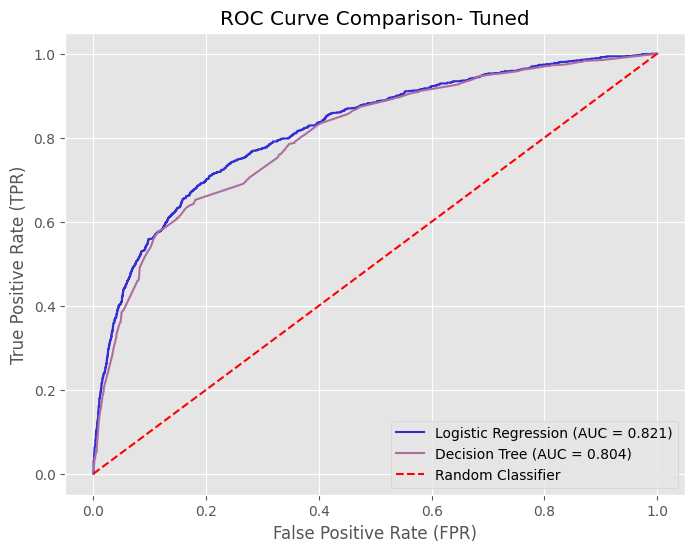

In [71]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log_tuned, tpr_log_tuned, color="#342CD4", label=f"Logistic Regression (AUC = {auc_log_tuned:.3f})")
plt.plot(fpr_tree_tuned, tpr_tree_tuned, "#AD6DA3", label=f"Decision Tree (AUC = {auc_tree_tuned:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison- Tuned")
plt.legend()
plt.show()



The ROC curve comparison highlights the impact of hyperparameter tuning on the Decision Tree model. The untuned Decision Tree achieved an **AUC of 0.649**, indicating limited ability to discriminate between classes. After tuning, the model’s performance improved significantly, achieving an **AUC of 0.804**, which demonstrates a stronger ability to correctly separate positive and negative cases. This shows that tuning the model increased the perfomance.

### Model Performance Comparison (Tuned vs Untuned)

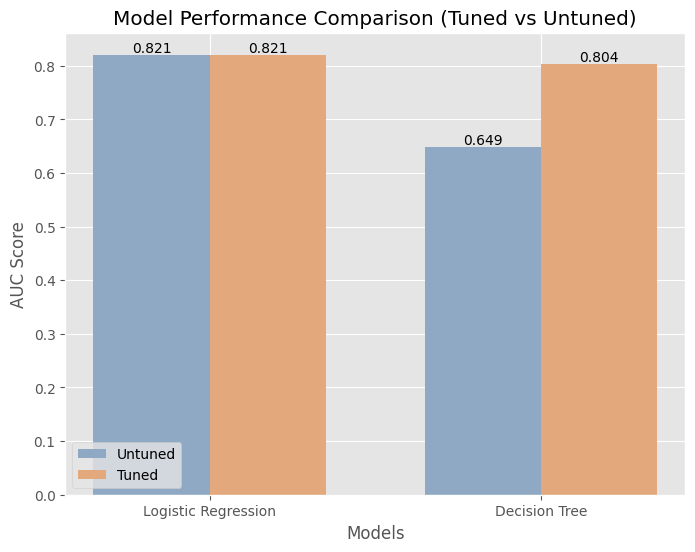

In [72]:
# Model names
models = ['Logistic Regression', 'Decision Tree']

# AUC scores
untuned_scores = [auc_log, auc_tree]
tuned_scores = [auc_log_tuned, auc_tree_tuned]

# Bar positions
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,6))

# Bars 
plt.bar(x - width/2, untuned_scores, width, color="#8FA8C3", label='Untuned')
plt.bar(x + width/2, tuned_scores, width, color="#E3A87C", label='Tuned')

# Labels and title
plt.xlabel("Models")
plt.ylabel("AUC Score")
plt.title("Model Performance Comparison (Tuned vs Untuned)")
plt.xticks(x, models)
plt.legend()

# Add values on top of bars
for i in range(len(models)):
    plt.text(x[i] - width/2, untuned_scores[i] + 0.005, f"{untuned_scores[i]:.3f}", ha='center')
    plt.text(x[i] + width/2, tuned_scores[i] + 0.005, f"{tuned_scores[i]:.3f}", ha='center')
    
plt.savefig('images/Model_Performance.png')
plt.show()


The bar chart shows how the models performed before and after tuning using AUC score.

- Logistic Regression performed very well even before tuning, with an AUC of 0.821, and tuning did not change its performance.
- Decision Tree improved significantly after tuning, increasing from 0.649 to 0.804.
- This shows that hyperparameter tuning had a strong impact on the Decision Tree, but little to no effect on Logistic Regression.

Logistic Regression is already well-optimized and gives consistently strong results. Decision Tree benefits greatly from tuning and becomes much more accurate after optimization.
Therefore, Logistic Regression is the best overall model because it has the highest AUC (0.821) and is more stable.


## Conclusion and Recommendations

### 1. Conclusion

The primary aim of this project was to develop a predictive model capable of identifying individuals likely to receive the H1N1 vaccine, supporting public health organizations in optimizing vaccination outreach. Using the 2009 National H1N1 Flu Survey data, the models were trained and evaluated, revealing several key insights:

**Model Performance:**  
- The initial, untuned Decision Tree model showed limited discriminative ability with an **AUC of 0.649**, indicating that it struggled to distinguish between individuals likely and unlikely to vaccinate.  
- After hyperparameter tuning, the Decision Tree’s performance improved substantially, achieving an **AUC of 0.804**, an accuracy of 82%, and better balance between precision and recall for both classes.  
- The tuned Logistic Regression model also performed well with a **test AUC of 0.821**, demonstrating strong discriminative capability and slightly outperforming the Decision Tree in identifying positive vaccination cases.  

**Key Insights:**  
- Higher AUC scores mean the models can distinguish well between people who are likely and unlikely to vaccinate.  
- The tuned models detect more of the minority group (people who get vaccinated), which is important for planning effective outreach.  
- Missing data in important variables like `health_insurance` (~46%) and `employment_industry` (~50%) had to be handled carefully to make the models reliable.

Overall, the tuned models meet the project objectives by providing accurate predictions and helping stakeholders identify people most likely to get vaccinated.

### 2. Recommendations

Based on model results and stakeholder needs, the following actions are recommended:

1. **Focus on Key Factors:** Target vaccination campaigns on the strongest predictors, like doctor recommendations and beliefs about vaccine effectiveness.  

2. **Reach Hesitant Groups:** Use the model to identify groups less likely to vaccinate and provide clear, targeted messages to reduce hesitancy.  

3. **Use the Tuned Models for Planning:** Deploy the Decision Tree (AUC = 0.804) and Logistic Regression (AUC = 0.821) to prioritize vaccine distribution and educational campaigns.  

4. **Collect Better Data:** Future surveys should aim for more complete information, especially in variables with high missing values, to improve predictions.  

5. **Update Models Regularly:** People’s perceptions change over time. Retraining the models with new survey data will ensure predictions remain accurate and help maintain effective outreach.

The tuned models provide a practical and reliable tool to support public health strategies, improve targeting, and make vaccination campaigns more effective.